# 2.1. Gradient Domain Editing

## Các thư viện setup

In [129]:
import numpy as np
import scipy as sp
import scipy.sparse.linalg as linalg
from scipy.sparse import diags
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

## Các hàm xử lý ảnh gốc ban đầu
Đây là các hàm dùng để load ảnh và show ảnh để thuận tiện cho việc so sánh

In [130]:
def load_img(image_name, DATAROOT, target_offset=None, scale=None):
    image_data = {}
    source = cv2.imread(DATAROOT + "source\\" + image_name)
    mask = cv2.imread(DATAROOT + "mask\\" + image_name)
    target = cv2.imread(DATAROOT + "target\\" + image_name)

    if source is None:
        raise FileNotFoundError(f"Không tìm thấy source: {DATAROOT + 'source\\' + image_name}")
    if mask is None:
        raise FileNotFoundError(f"Không tìm thấy mask:   {DATAROOT + 'mask\\' + image_name}")
    if target is None:
        raise FileNotFoundError(f"Không tìm thấy target: {DATAROOT + 'target\\' + image_name}")

    # Normalize the images to [0, 1]
    image_data['source'] = cv2.normalize(source.astype('float32'), None, 0.0, 1.0, cv2.NORM_MINMAX)
    image_data['mask'] = cv2.normalize(mask.astype('float32'), None, 0.0, 1.0, cv2.NORM_MINMAX)
    image_data['target'] = cv2.normalize(target.astype('float32'), None, 0.0, 1.0, cv2.NORM_MINMAX)

    if target_offset is None:
        target_path = DATAROOT + "target\\" + image_name
        source_path = DATAROOT + "source\\" + image_name
        mask_path = DATAROOT + "mask\\" + image_name
        dims, scale = select_offset(target_path, source_path, mask_path)
        image_data['dims'] = dims
    else:
        image_data['dims'] = target_offset

    # Scale source and mask if user adjusted size
    if scale is not None and scale != 1.0:
            Hs, Ws = image_data['source'].shape[:2]
            new_H = max(1, int(round(Hs * scale)))
            new_W = max(1, int(round(Ws * scale)))
            image_data['source'] = cv2.resize(image_data['source'], (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            image_data['mask']   = cv2.resize(image_data['mask'],   (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            print(f"Scaled source & mask by {scale:.2f}x → {new_H}x{new_W}")
    return image_data

def display_images(image_data):
    plt.figure(figsize=(16, 16))
    for i in range(3):
        if i == 0:
            img_string = 'source'
        elif i == 1:
            img_string = 'mask'
        else:
            img_string = 'target'
        img = image_data[img_string]
        plt.subplot(1, 3, i + 1)
        plt.imshow(img[:,:,[2, 1, 0]])  # Convert BGR to RGB for display

def select_offset(target_path, source_path, mask_path):
    """
    Controls:
      - Mouse move / Left-click : choose placement position
      - Scroll UP / press '+'   : scale source+mask UP  (+5% per step)
      - Scroll DOWN / press '-' : scale source+mask DOWN (-5% per step)
      - Enter                   : confirm
    """
    target = cv2.imread(target_path)
    source_orig = cv2.imread(source_path)
    mask_orig   = cv2.imread(mask_path)

    Ht, Wt = target.shape[:2]
    Hs_orig, Ws_orig = source_orig.shape[:2]

    state = {
        'offset': [0, 0],
        'scale': 1.0,
        'source': source_orig.copy(),
        'mask': mask_orig.copy(),
    }

    WIN = "Select Offset & Scale (scroll=resize, Enter=confirm)"

    def redraw(y, x):
        src  = state['source']
        msk  = state['mask']
        Hs, Ws = src.shape[:2]
        display = target.copy()
        Hmax = min(y + Hs, Ht)
        Wmax = min(x + Ws, Wt)
        if Hmax > y and Wmax > x:
            src_crop  = src[0:Hmax - y, 0:Wmax - x]
            mask_crop = msk[0:Hmax - y, 0:Wmax - x] / 255.0
            roi = display[y:Hmax, x:Wmax]
            display[y:Hmax, x:Wmax] = (1 - mask_crop * 0.7) * roi + (mask_crop * 0.7) * src_crop
        cv2.rectangle(display, (x, y), (min(x+Ws,Wt), min(y+Hs,Ht)), (0, 255, 0), 2)
        sc = state['scale']
        cv2.putText(display,
                    f"Offset:({y},{x})  Scale:{sc:.2f}x ({int(Hs_orig*sc)}x{int(Ws_orig*sc)})",
                    (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)
        cv2.imshow(WIN, display)

    def mouse_callback(event, x, y, flags, param):
        if event in (cv2.EVENT_LBUTTONDOWN, cv2.EVENT_MOUSEMOVE):
            if event == cv2.EVENT_LBUTTONDOWN:
                state['offset'] = [y, x]
                # print(f"Selected offset: H0={y}, W0={x}")
            redraw(state['offset'][0], state['offset'][1])

        elif event == cv2.EVENT_MOUSEWHEEL:
            # flags > 0 → scroll up → scale up
            delta = 0.05 if flags > 0 else -0.05
            state['scale'] = max(0.05, state['scale'] + delta)
            new_H = max(1, int(round(Hs_orig * state['scale'])))
            new_W = max(1, int(round(Ws_orig * state['scale'])))
            state['source'] = cv2.resize(source_orig, (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            state['mask']   = cv2.resize(mask_orig,   (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            # print(f"Scale: {state['scale']:.2f}x → source size: {new_H}x{new_W}")
            redraw(state['offset'][0], state['offset'][1])

    cv2.imshow(WIN, target)
    cv2.setMouseCallback(WIN, mouse_callback)

    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == 13:   # Enter to confirm
            break
        elif key == ord('+') or key == ord('='):   # '+' scale up
            state['scale'] = state['scale'] + 0.05
            new_H = max(1, int(round(Hs_orig * state['scale'])))
            new_W = max(1, int(round(Ws_orig * state['scale'])))
            state['source'] = cv2.resize(source_orig, (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            state['mask']   = cv2.resize(mask_orig,   (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            print(f"Scale: {state['scale']:.2f}x → source size: {new_H}x{new_W}")
            redraw(state['offset'][0], state['offset'][1])
        elif key == ord('-'):   # '-' scale down
            state['scale'] = max(0.05, state['scale'] - 0.05)
            new_H = max(1, int(round(Hs_orig * state['scale'])))
            new_W = max(1, int(round(Ws_orig * state['scale'])))
            state['source'] = cv2.resize(source_orig, (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            state['mask']   = cv2.resize(mask_orig,   (new_W, new_H), interpolation=cv2.INTER_LINEAR)
            print(f"Scale: {state['scale']:.2f}x → source size: {new_H}x{new_W}")
            redraw(state['offset'][0], state['offset'][1])

    cv2.destroyAllWindows()
    print(f"Confirmed — offset: {state['offset']}, scale: {state['scale']:.2f}x")
    return state['offset'], state['scale']


## Tiền xử lý dữ liệu
Mục đích của hàm này là căn chỉnh source + mask vào đúng vị trí trên target trước khi blend.

Nếu Ho < 0, nghĩa là bạn muốn đặt source lên trên viền target — phần bị tràn ra ngoài phải bị cắt bỏ. Tương tự với Wo.


In [131]:
def preprocess_images(image_data):
    source = image_data['source'].copy()
    mask = image_data['mask'].copy()
    target = image_data['target'].copy()
    
    # Get image shapes and offset dimensions
    Hs, Ws, _ = source.shape
    Ht, Wt, _ = target.shape
    Ho, Wo = image_data['dims']

    print(f"Source shape: {Hs}x{Ws}")
    print(f"Target shape: {Ht}x{Wt}")
    print(f"Offset (Ho, Wo): ({Ho}, {Wo})")
    print(f"Target region: H[{Ho}:{min(Ho+Hs,Ht)}] W[{Wo}:{min(Wo+Ws,Wt)}]")

    # Adjust the source and mask images based on the offsets (if negative)
    if Ho < 0:
        mask = np.roll(mask, shift=Ho, axis=0)
        source = np.roll(source, shift=Ho, axis=0)
        mask[Ho + Hs:,:,:] = 0
        source[Ho + Hs:,:,:] = 0
        Ho = 0
        
    
    if Wo < 0:
        mask = np.roll(mask, shift=Wo, axis=1)
        source = np.roll(source, shift=Wo, axis=1)
        mask[:, Wo + Ws:,:] = 0
        source[:, Wo + Ws:,:] = 0
        Wo = 0
    
    # Mask region on target
    H_min = Ho
    H_max = min(Ho + Hs, Ht)
    W_min = Wo
    W_max = min(Wo + Ws, Wt)

    # Crop source and mask if they exceed target dimensions
    source = source[0:min(Hs, Ht - Ho), 0:min(Ws, Wt - Wo), :]
    mask = mask[0:min(Hs, Ht - Ho), 0:min(Ws, Wt - Wo), :]

    return {'source': source, 'mask': mask, 'target': target, 'dims': (H_min, H_max, W_min, W_max)}


## Naive copy
Chỉ copy-paste đơn giản sử dụng công thức chuẩn của alpha blending: 

$$C = αF + (1−α)B $$

F: màu foreground

B: màu background

C: màu kết quả

In [132]:
def naive_copy(image_data):
    source = image_data['source']
    mask = image_data['mask']
    target = image_data['target']
    dims = image_data['dims']

    target[dims[0]:dims[1], dims[2]:dims[3], :] = target[dims[0]:dims[1],dims[2]:dims[3],:] * (1 - mask) + source * mask

    return target

## Poisson blending
Poisson blending copy gradient khai thác sự thay đổi giữa các pixel liền kề, kết quả là vật thể ghép vào sẽ tự động thích nghi với ánh sáng của ảnh nền. Việc thực hiện Poisson blending là giải quyết bài toán dưới đây.

Tìm ảnh $f trong vùng mask sao cho:

$$\min_f \iint_\Omega |\nabla f - \mathbf{v}|^2$$

Với điều kiện biên: $f = f^*$ (target) tại biên mask $\partial\Omega$, trong đó $\mathbf{v}$ là guidance field (gradient của source).

---

Lấy đạo hàm theo $f$ và cho bằng 0:

$$\nabla^2 f = \text{div}(\mathbf{v})$$

Trong đó $\nabla^2 f$ là **Laplacian**:

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

Đạo hàm bậc 1 rời rạc:

$$\frac{\partial f}{\partial x} \approx f(i+1) - f(i)$$

Đạo hàm bậc 2 = đạo hàm của đạo hàm bậc 1:

$$\frac{\partial^2 f}{\partial x^2} \approx [f(i+1) - f(i)] - [f(i) - f(i-1)] = f(i+1) - 2f(i) + f(i-1)$$

Tương tự theo chiều $y$ (bước nhảy $W$):

$$\frac{\partial^2 f}{\partial y^2} \approx f(i+W) - 2f(i) + f(i-W)$$

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

$$= [f(i+1) - 2f(i) + f(i-1)] + [f(i+W) - 2f(i) + f(i-W)]$$

$$= -4f(i) + f(i-1) + f(i+1) + f(i-W) + f(i+W)$$

Đặt $\nabla^2 f = \text{div}(\mathbf{v})$ và chuyển vế:

$$\boxed{4f(i) - f(i-1) - f(i+1) - f(i-W) - f(i+W) = \text{div}(\mathbf{v}_i)}$$

Đây chính là một hàng trong hệ phương trình $\mathbf{L}\mathbf{f} = \mathbf{b}$, với:
- $\mathbf{L}$: ma trận Laplacian thưa (sparse)
- $\mathbf{f}$: vector ảnh kết quả cần tìm
- $\mathbf{b}$: vector guidance field $= \text{div}(\mathbf{v})$


In [133]:
def get_subimg(image, dims):
    return image[dims[0]:dims[1], dims[2]:dims[3]]

def poisson_blend(image, GRAD_MIX):
    mask = image['mask']
    Hs, Ws = mask.shape
    num_pixels = Hs * Ws

    source = image['source'].flatten(order='C')
    target_subimg = get_subimg(image['target'], image['dims']).flatten(order='C')
    mask_flat = mask.flatten(order='C')
    mask_bool = mask_flat > 0.99
    # Build the sparse Laplacian block matrix 
    diag_main = np.where(mask_bool, 4.0, 1.0) # 4 in masked regions, 1 in unmasked regions

    diag_up = np.zeros(num_pixels - Ws)
    diag_down = np.zeros(num_pixels - Ws)
    diag_left = np.zeros(num_pixels - 1)
    diag_right = np.zeros(num_pixels - 1)

    ## Neighbor up
    valid_up = mask_bool[Ws:]
    diag_up = np.where(valid_up, -1.0, 0.0)

    ## Neighbor down
    valid_down = mask_bool[:num_pixels - Ws]
    diag_down = np.where(valid_down, -1.0, 0.0)

    ## Neighbor left
    valid_left = mask_bool[1:].copy()
    valid_left[Ws-1::Ws] = False  # Invalidate left neighbors at the start of each row
    diag_left = np.where(valid_left, -1.0, 0.0)

    ## Neighbor right
    valid_right = mask_bool[:num_pixels - 1].copy()
    valid_right[Ws-1::Ws] = False  # Invalidate right neighbors at the start of each row
    diag_right = np.where(valid_right, -1.0, 0.0)


    laplacian = diags([diag_main, diag_up, diag_down, diag_left, diag_right], 
                      [0, -Ws, Ws, -1, 1], 
                      shape=(num_pixels, num_pixels), format='csr')
    
    # Build guidance field
    guidance_field = target_subimg.copy()

    src_2d = source.reshape(Hs, Ws)
    tgt_2d = target_subimg.reshape(Hs, Ws)

    ## Gradient source
    grad_up_s = src_2d - np.roll(src_2d, shift=1, axis=0); grad_up_s[0, :] = src_2d[0, :]
    grad_down_s = src_2d - np.roll(src_2d, shift=-1, axis=0); grad_down_s[-1, :] = src_2d[-1, :]
    grad_left_s = src_2d - np.roll(src_2d, shift=1, axis=1); grad_left_s[:, 0] = src_2d[:, 0]
    grad_right_s =src_2d - np.roll(src_2d, shift=-1, axis=1); grad_right_s[:, -1] = src_2d[:, -1]
    
    if GRAD_MIX:
        grad_up_t = tgt_2d - np.roll(tgt_2d, shift=1, axis=0); grad_up_t[0, :] = tgt_2d[0, :]
        grad_down_t = tgt_2d - np.roll(tgt_2d, shift=-1, axis=0); grad_down_t[-1, :] = tgt_2d[-1, :]
        grad_left_t = tgt_2d - np.roll(tgt_2d, shift=1, axis=1); grad_left_t[:, 0] = tgt_2d[:, 0]
        grad_right_t = tgt_2d - np.roll(tgt_2d, shift=-1, axis=1); grad_right_t[:, -1] = tgt_2d[:, -1]

        _compare = lambda x, y: np.where(np.abs(x) > np.abs(y), x, y)
        g_up = _compare(grad_up_s, grad_up_t)
        g_down = _compare(grad_down_s, grad_down_t)
        g_left = _compare(grad_left_s, grad_left_t)
        g_right = _compare(grad_right_s, grad_right_t)
    else:
        g_up = grad_up_s
        g_down = grad_down_s
        g_left = grad_left_s
        g_right = grad_right_s

    div = (g_up + g_down + g_left + g_right).flatten(order='C')
    guidance_field = np.where(mask_bool, div, target_subimg)

    return [laplacian, guidance_field]

## Laplacian Blending

Gaussian pyramid được xây dựng bằng phép tích chập với **Gaussian kernel** $G_\sigma$:

$$G_k = (I * g^k)$$

Trong đó:
- $I$ là ảnh gốc
- $g$ là Gaussian kernel (thường 5×5)
- $k$ là level của pyramid

$$g = \frac{1}{16}\begin{bmatrix} 1&2&1\\2&4&2\\1&2&1 \end{bmatrix}$$

Mỗi level làm mờ thêm → loại bỏ tần số cao, chỉ giữ tần số thấp.

---

Laplacian tại level $k$:

$$L_k = G_k - \text{pyrUp}(G_{k+1})$$

**Tính chất quan trọng** — có thể reconstruct hoàn hảo:

$$I = L_0 + \text{pyrUp}(L_1 + \text{pyrUp}(L_2 + \ldots))$$

Không mất thông tin — chỉ là biểu diễn khác của ảnh gốc.

---

Thay vì blend trực tiếp như Naive blending, ta blend **từng dải tần số**:

$$\tilde{L}_k(x,y) = M_k(x,y) \cdot L_k^S(x,y) + (1 - M_k(x,y)) \cdot L_k^T(x,y)$$

Trong đó $M_k$ là **Gaussian pyramid của mask** tại level $k$:

$$M_k = \text{pyrDown}^k(M_0)$$

**Điểm mấu chốt:** $M_k$ càng mờ khi $k$ càng lớn vì qua nhiều lần Gaussian blur:

$$M_k = M_0 * g^k$$

Nên:
- Level **thô** (màu sắc tổng thể): mask rất mờ → transition rất mượt
- Level **mịn** (chi tiết, cạnh): mask sắc nét hơn → giữ chi tiết rõ

In [134]:
def laplacian_blend(image, num_levels=6):
    source = image['source']
    mask   = image['mask']
    target = image['target']
    H_min, H_max, W_min, W_max = image['dims']

    target_region = target[H_min:H_max, W_min:W_max].copy()

    src_u8 = (source        * 255).astype(np.uint8)
    tgt_u8 = (target_region * 255).astype(np.uint8)
    msk_u8 = (mask          * 255).astype(np.uint8)

    mask_bin = (msk_u8 > 128).astype(np.uint8)
    if mask_bin.ndim == 2:
        mask_bin = mask_bin[:, :, np.newaxis]
    src_u8 = src_u8 * mask_bin + tgt_u8 * (1 - mask_bin)

    # Gaussian pyramid
    def build_gaussian_pyramid(img, levels):
        gp, cur = [img.copy()], img.copy()
        for _ in range(levels):
            cur = cv2.pyrDown(cur)
            gp.append(cur)
        return gp  # index 0=finest, index levels=coarsest

    gp_src  = build_gaussian_pyramid(src_u8,  num_levels)
    gp_tgt  = build_gaussian_pyramid(tgt_u8,  num_levels)
    gp_mask = build_gaussian_pyramid(msk_u8,  num_levels)

    # Laplacian pyramid
    def build_laplacian_pyramid(gp, levels):
        lp = [gp[levels].astype(np.float32)]   # coarsest giữ nguyên
        for i in range(levels, 0, -1):
            up  = cv2.pyrUp(gp[i])
            up  = cv2.resize(up, (gp[i-1].shape[1], gp[i-1].shape[0]))
            lap = gp[i-1].astype(np.float32) - up.astype(np.float32)
            lp.append(lap)
        return lp  # index 0=coarsest, index levels=finest

    lp_src = build_laplacian_pyramid(gp_src, num_levels)
    lp_tgt = build_laplacian_pyramid(gp_tgt, num_levels)

    # Blend
    blended_pyramid = []
    for i, (lap_s, lap_t) in enumerate(zip(lp_src, lp_tgt)):
        # lp index 0=coarsest → mask index num_levels=coarsest
        m = gp_mask[num_levels - i].astype(np.float32) / 255.0
        m = cv2.resize(m, (lap_s.shape[1], lap_s.shape[0]))
        if m.ndim == 2:
            m = m[:, :, np.newaxis]
        blended_pyramid.append(lap_s * m + lap_t * (1.0 - m))

    # Reconstruct
    result = blended_pyramid[0]
    for i in range(1, num_levels + 1):
        result = cv2.pyrUp(result)
        result = cv2.resize(result, (blended_pyramid[i].shape[1], blended_pyramid[i].shape[0]))
        result += blended_pyramid[i]

    result = np.clip(result / 255.0, 0.0, 1.0)

    output = target.copy()
    output[H_min:H_max, W_min:W_max] = result
    return output


## Hàm giải phương trình tuyến tính và hàm ghép ảnh

In [135]:
def linear_solver(A, b, dims):
    x = linalg.spsolve(A.tocsc(), b)
    return np.reshape(x, (dims[0], dims[1]))

def stitch_img(source, target, dims):
    target[dims[0]:dims[1], dims[2]:dims[3], :] = source
    return target

def blend_img(data, BLEND_TYPE, GRAD_MIX = False, NUM_LV = 6):
    if BLEND_TYPE == 0:
        image_result = naive_copy(data)
    elif BLEND_TYPE == 1:
        image_result = laplacian_blend(data, NUM_LV)
    elif BLEND_TYPE == 2:
        equation_param = []
        ch_data = {}
        # Construct Poisson equation for each channel
        for ch in range(3):
            ch_data['source'] = data['source'][:, :, ch]
            ch_data['mask'] = data['mask'][:, :, ch]
            ch_data['target'] = data['target'][:, :, ch]
            ch_data['dims'] = data['dims']
            equation_param.append(poisson_blend(ch_data, GRAD_MIX))

        # Solve the Poisson equation for each channel
        image_result = np.empty_like(data['source'])
        for i in range(3):
            image_result[:, :, i] = linear_solver(equation_param[i][0], equation_param[i][1], (data['source'].shape[0], data['source'].shape[1]))
            
        image_result = stitch_img(image_result, data['target'].copy(), data['dims'])
    else:
        raise ValueError("Invalid BLEND_TYPE. Must be 0, 1, or 2.")
    
    return image_result

## Main

Scale: 0.95x → source size: 404x570
Scale: 0.90x → source size: 382x540
Scale: 0.85x → source size: 361x510
Scale: 0.80x → source size: 340x480
Scale: 0.75x → source size: 319x450
Scale: 0.70x → source size: 297x420
Scale: 0.65x → source size: 276x390
Scale: 0.60x → source size: 255x360
Scale: 0.55x → source size: 234x330
Confirmed — offset: [0, 0], scale: 0.55x
Scaled source & mask by 0.55x → 234x330
Source shape: 234x330
Target shape: 408x612
Offset (Ho, Wo): (0, 0)
Target region: H[0:234] W[0:330]
Saved to C:\Users\ASUS\Downloads\CV_Project_2\Images\result\03.jpg


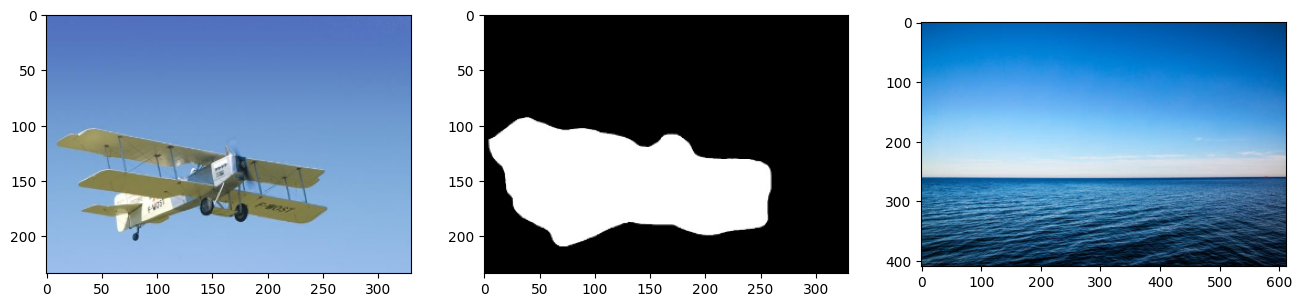

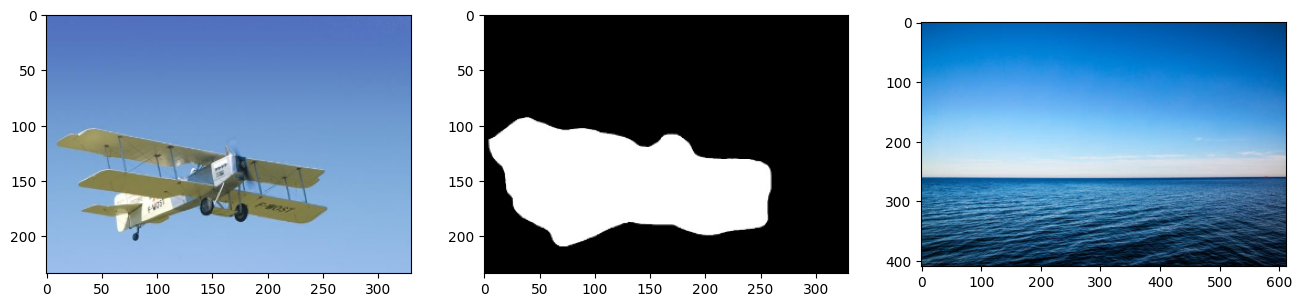

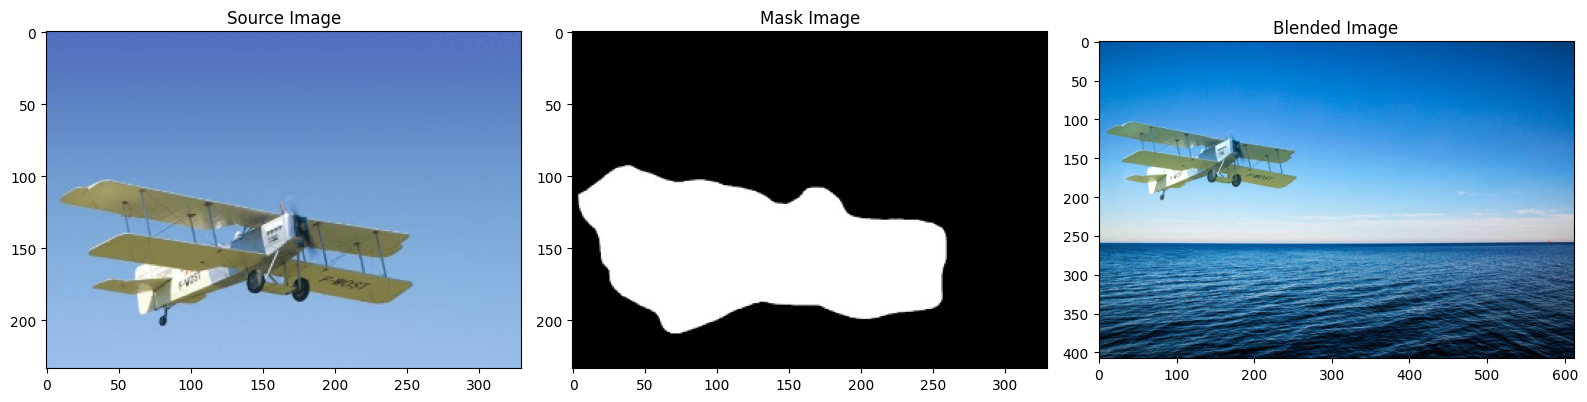

In [136]:
DATA_ROOT = 'C:\\Users\\ASUS\\Downloads\\CV_Project_2\\Images\\'
BLEND_TYPE = 2
NUM_LV = 3
GRAD_MIX = True
IMAGE_NAME = "03.jpg"

target_offsets = [[200, 21, 1.0], [-300, -100, 1.0], [-150, 10, 1.0]]

USE_MANUAL_OFFSET = True

if USE_MANUAL_OFFSET:
    offset = None
    scale = None
else:
    offset = target_offsets[int(IMAGE_NAME[:-4]) - 1]
    scale = offset[2]
    offset = offset[:2]

image =  load_img(IMAGE_NAME, DATA_ROOT, target_offset=offset, scale=scale)
display_images(image)

data = preprocess_images(image)
display_images(data)
final_image = blend_img(data, BLEND_TYPE, GRAD_MIX, NUM_LV)

# Plot result
final_image = np.clip(final_image, 0, 1)
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1); plt.title('Source Image'); plt.imshow(image['source'][:,:,[2, 1, 0]])
plt.subplot(1, 3, 2); plt.title('Mask Image'); plt.imshow(image['mask'][:,:,[2, 1, 0]])
plt.subplot(1, 3, 3); plt.title('Blended Image'); plt.imshow(final_image[:,:,[2, 1, 0]])
plt.tight_layout()

# Save the result
save_img = (final_image * 255).astype(np.uint8)
cv2.imwrite(DATA_ROOT + "result\\" + IMAGE_NAME, save_img, [cv2.IMWRITE_JPEG_QUALITY, 90])
print(f"Saved to {DATA_ROOT + 'result\\' + IMAGE_NAME}")


